# Job Shortage Analysis

This notebook identifies which university-degree fields have experienced occupation shortages in Australia, using the annual Occupation Shortage List (OSL) published by the Department of Employment and Workplace Relations (2021–2025). Only **Skill Level 1** occupations are included — those that formally require a bachelor's degree or higher under the ANZSCO framework.

In [1]:
import warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent
OSL_DIR = ROOT / 'EmploymentShortages'

# ANZSCO sub-major group (first 2 digits) -> CategoryKey
# Group 23 split further by minor group (3 digits)
GROUP23 = {'231': 4, '232': 3, '233': 3, '234': 1, '235': 3}
ANZSCO_MAP = {
    '11': 8, '12': 5, '13': 8, '14': 11,   # Managers
    '21': 10, '22': 8,                       # Business/Arts professionals
    '24': 7, '25': 6, '26': 2, '27': 9,     # Education/Health/ICT/Legal
}

CATEGORY_NAMES = {
    1: 'Natural & Physical Science', 2: 'Information Technology',
    3: 'Engineering & Related Tech',  4: 'Architecture & Building',
    5: 'Environment & Related',       6: 'Health',
    7: 'Education',                   8: 'Management & Commerce',
    9: 'Society & Culture',          10: 'Creative Arts',
}

def code_to_key(code):
    s = str(int(code)).zfill(6)
    if s[:2] == '23':
        return GROUP23.get(s[:3])
    return ANZSCO_MAP.get(s[:2])

print('Setup complete. OSL directory:', OSL_DIR)

Setup complete. OSL directory: C:\Users\neddp\ECC3479-Project-JRGS\EmploymentShortages


In [2]:
YEARS = [2021, 2022, 2023, 2024, 2025]
rows = []
for yr in YEARS:
    df = pd.read_csv(OSL_DIR / f'OSL {yr} (ANZSCO 6).csv')
    sl1 = df[df['Skill Level'] == 1].copy()
    sl1['CategoryKey'] = sl1['Code'].apply(code_to_key)
    sl1 = sl1.dropna(subset=['CategoryKey'])
    sl1['CategoryKey'] = sl1['CategoryKey'].astype(int)
    for key, name in CATEGORY_NAMES.items():
        sub      = sl1[sl1['CategoryKey'] == key]
        n        = len(sub)
        shortage = (sub['National Shortage Rating'] == 'Shortage').sum()
        regional = (sub['National Shortage Rating'] == 'Regional shortage').sum()
        rows.append({
            'Year': yr, 'CategoryKey': key, 'Category': name,
            'Total':    n,
            'Shortage': int(shortage),
            'Regional': int(regional),
            'Shortage%': round(shortage / n * 100, 1) if n > 0 else 0.0,
        })

data = pd.DataFrame(rows)

# Summary table: shortage count
count_table = data.pivot_table(
    index='Category', columns='Year', values='Shortage', aggfunc='sum'
).astype(int)

# Summary table: shortage rate
rate_table = data.pivot_table(
    index='Category', columns='Year', values='Shortage%', aggfunc='mean'
).round(1)

print('=== National shortage count (Skill Level 1 occupations) ===')
display(count_table)
print()
print('=== Shortage rate % (share of occupations in national shortage) ===')
display(rate_table)

=== National shortage count (Skill Level 1 occupations) ===


Year,2021,2022,2023,2024,2025
Category,,,,,
Architecture & Building,0,0,3,3,5
Creative Arts,0,0,0,0,1
Education,1,8,9,9,9
Engineering & Related Tech,10,16,26,24,16
Environment & Related,4,1,1,0,0
Health,8,58,66,65,61
Information Technology,10,23,20,15,6
Management & Commerce,12,10,15,10,4
Natural & Physical Science,10,9,10,10,11



=== Shortage rate % (share of occupations in national shortage) ===


Year,2021,2022,2023,2024,2025
Category,,,,,
Architecture & Building,0.0,0.0,60.0,60.0,100.0
Creative Arts,0.0,0.0,0.0,0.0,2.9
Education,5.9,42.1,47.4,47.4,47.4
Engineering & Related Tech,30.3,47.1,76.5,70.6,47.1
Environment & Related,16.7,3.8,3.8,0.0,0.0
Health,10.4,70.7,80.5,79.3,74.4
Information Technology,38.5,79.3,69.0,51.7,20.7
Management & Commerce,14.0,10.8,16.1,10.8,4.3
Natural & Physical Science,33.3,26.5,29.4,29.4,32.4


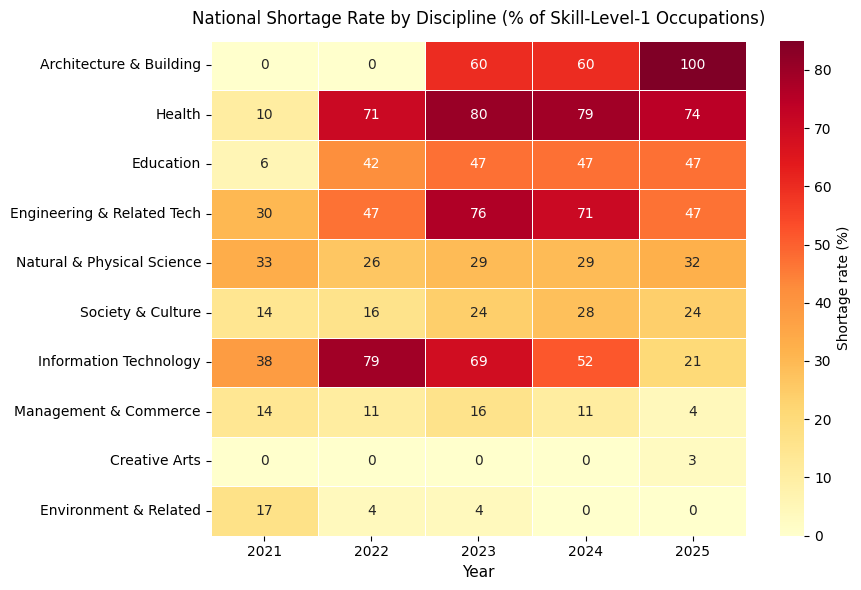

In [3]:
# Order categories by 2025 shortage rate descending
order = rate_table[2025].sort_values(ascending=False).index.tolist()
heat_data = rate_table.loc[order]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(
    heat_data,
    annot=True, fmt='.0f', annot_kws={'size': 10},
    cmap='YlOrRd', vmin=0, vmax=85,
    linewidths=0.4, linecolor='white',
    cbar_kws={'label': 'Shortage rate (%)'},
    ax=ax,
)
ax.set_title('National Shortage Rate by Discipline (% of Skill-Level-1 Occupations)', fontsize=12, pad=12)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=10)
plt.tight_layout()
plt.show()

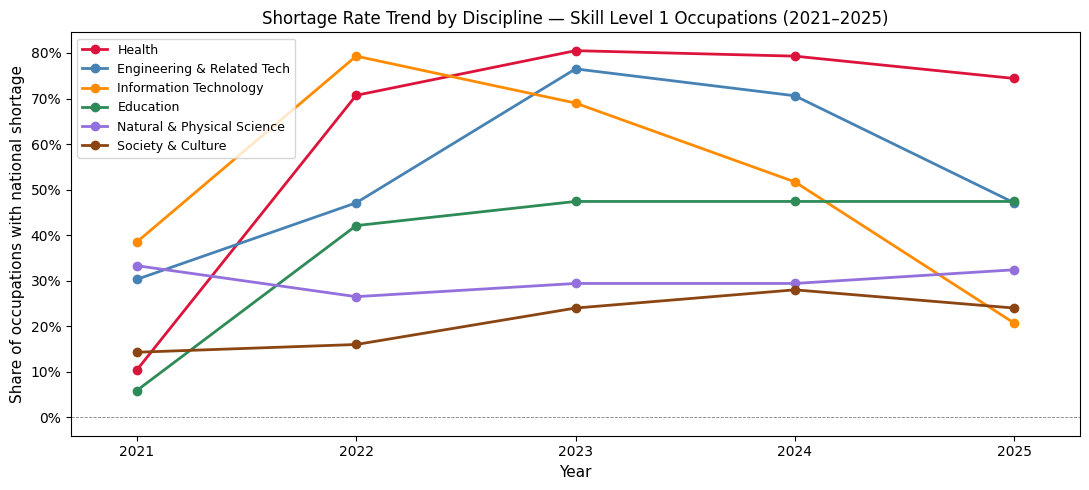

In [4]:
# Line chart — top fields only (exclude low-shortage categories)
highlight = [
    'Health', 'Engineering & Related Tech', 'Information Technology',
    'Education', 'Natural & Physical Science', 'Society & Culture',
]
colours = {
    'Health':                    'crimson',
    'Engineering & Related Tech':'steelblue',
    'Information Technology':    'darkorange',
    'Education':                 'seagreen',
    'Natural & Physical Science':'mediumpurple',
    'Society & Culture':         'saddlebrown',
}

fig, ax = plt.subplots(figsize=(11, 5))
for cat in highlight:
    sub = data[data['Category'] == cat].sort_values('Year')
    ax.plot(sub['Year'], sub['Shortage%'], 'o-', color=colours[cat],
            linewidth=2, markersize=6, label=cat)

ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(2020.7, 2025.3)
ax.set_xticks(YEARS)
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Share of occupations with national shortage', fontsize=11)
ax.set_title('Shortage Rate Trend by Discipline — Skill Level 1 Occupations (2021–2025)', fontsize=12)
ax.axhline(0, color='gray', linewidth=0.6, linestyle='--')
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

## Key Findings

### Persistently high shortage fields

**Health** has the largest and most sustained shortage. The shortage rate rose from 10% in 2021 to ~80% by 2023 and has remained at 74–80% through 2025. This spans 82 Skill Level 1 occupations including nursing, medicine, allied health, and pharmacy — the broadest shortage in the dataset.

**Engineering & Related Tech** peaked at 77% in 2023 (26 of 34 occupations in national shortage) and has eased to 47% in 2025. The spike reflects post-COVID construction and infrastructure demand outpacing graduate supply.

**Education** rose sharply from 6% in 2021 to 42% in 2022 (8 of 19 occupations), where it has stabilised at ~47% through 2025. Teacher shortages are now a persistent feature rather than a temporary disruption.

### Fields that have eased

**Information Technology** had the sharpest peak — 79% shortage in 2022 (23 of 29 occupations) — but has unwound significantly to 21% by 2025. This likely reflects both increased IT graduate supply responding to JRG fee reductions and normalisation of demand after the pandemic-driven digital surge.

**Environment & Related** had a modest shortage in 2021 (17%) that has since fully resolved (0% from 2024).

### Stable or low-shortage fields

**Natural & Physical Science** maintains a consistently moderate shortage rate (~29–33%) across all five years — no dramatic surge or resolution, suggesting structural rather than cyclical pressure.

**Society & Culture** has shown a slow upward trend (14% → 28% → 24%), driven primarily by legal and social work occupations.

**Management & Commerce** and **Creative Arts** show minimal shortage throughout (4% and 3% respectively in 2025), consistent with these fields having ample graduate supply relative to demand.

### Overall pattern

The post-COVID period (2021–2022) saw shortages emerge or intensify across most degree-level fields simultaneously. By 2025, shortages have eased in IT and Engineering but remain acute in Health and Education — the two fields that received the largest JRG fee reductions, suggesting those policy incentives were responding to genuine labour market signals.